# Cognifyz Data Analysis Internship — Level 2

## Restaurant Dataset Analysis

This notebook contains the analysis performed for **Level 2 tasks** of the Cognifyz Data Analysis Internship.

## Introduction

This project analyzes restaurant data provided as part of the Cognifyz Data Analysis Internship.

The objective of Level 2 is to perform more detailed analysis of the restaurant dataset, explore relationships between different attributes, create meaningful visualizations, and derive useful insights from the data.

## Level 2 Tasks

The following tasks will be performed:

1. **Restaurant Ratings** — Analyze the distribution of restaurant ratings and identify patterns in the ratings.
2. **Cuisine Combination** — Analyze the relationship between cuisines and restaurant ratings.
3. **Geographical Analysis** — Explore the geographical distribution of restaurants and identify relevant patterns.
4. **Restaurant Chains** — Identify restaurant chains and analyze their presence and ratings.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../Dataset/Dataset .csv")

In [3]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


**Task 1 - Restaurant Ratings**

In [4]:
df['Aggregate rating'].value_counts().sort_index()

Aggregate rating
0.0    2148
1.8       1
1.9       2
2.0       7
2.1      15
2.2      27
2.3      47
2.4      87
2.5     110
2.6     191
2.7     250
2.8     315
2.9     381
3.0     468
3.1     519
3.2     522
3.3     483
3.4     498
3.5     480
3.6     458
3.7     427
3.8     400
3.9     335
4.0     266
4.1     274
4.2     221
4.3     174
4.4     144
4.5      95
4.6      78
4.7      42
4.8      25
4.9      61
Name: count, dtype: int64

In [5]:
rating_ranges = pd.cut(
    df['Aggregate rating'],
    bins=[0, 2, 3, 4, 5],
    labels=['1.0–1.9', '2.0–2.9', '3.0–3.9', '4.0–4.9']
)

rating_ranges.value_counts().sort_index()

Aggregate rating
1.0–1.9      10
2.0–2.9    1891
3.0–3.9    4388
4.0–4.9    1114
Name: count, dtype: int64

In [6]:
df['Votes'].mean()

np.float64(156.909747670401)

Conclusion: Most restaurants have an aggregate rating between 3.0 and 3.9, making it the most common rating range. On average, each restaurant receives approximately 156.91 votes.

**Task 2 - Cuisine Combination**

In [7]:
df['Cuisines'].value_counts().head(10)

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

In [9]:
cuisine_rating = df.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False)

In [10]:
cuisine_rating.head(10)

Cuisines
Burger, Bar Food, Steak            4.9
American, Burger, Grill            4.9
American, Caribbean, Seafood       4.9
American, Coffee and Tea           4.9
Mexican, American, Healthy Food    4.9
Italian, Bakery, Continental       4.9
BBQ, Breakfast, Southern           4.9
European, German                   4.9
Hawaiian, Seafood                  4.9
Sunda, Indonesian                  4.9
Name: Aggregate rating, dtype: float64

In [11]:
cuisine_analysis = df.groupby('Cuisines').agg(
    restaurant_count=('Cuisines', 'count'),
    average_rating=('Aggregate rating', 'mean')
).sort_values('restaurant_count', ascending=False)

cuisine_analysis.head(10)

,restaurant_count,average_rating
Cuisines,,
North Indian,936,1.672329
"North Indian, Chinese",511,2.421722
Chinese,354,2.042090
Fast Food,354,2.118362
"North Indian, Mughlai",334,2.888623
Cafe,299,2.890970
Bakery,218,1.924312
"North Indian, Mughlai, Chinese",197,2.568528
"Bakery, Desserts",170,2.317647


The most common multi-cuisine combination is North Indian and Chinese, with 511 restaurants. The analysis shows that cuisine popularity does not necessarily correspond to higher ratings. Among the most common cuisine entries, North Indian, Mughlai and Cafe have the highest average rating of approximately 2.89.

**Task 3 - Geographic Analysis**

In [12]:
df[['Latitude', 'Longitude']].head()

,Latitude,Longitude
0,14.565443,121.027535
1,14.553708,121.014101
2,14.581404,121.056831
3,14.585318,121.056475
4,14.584450,121.057508


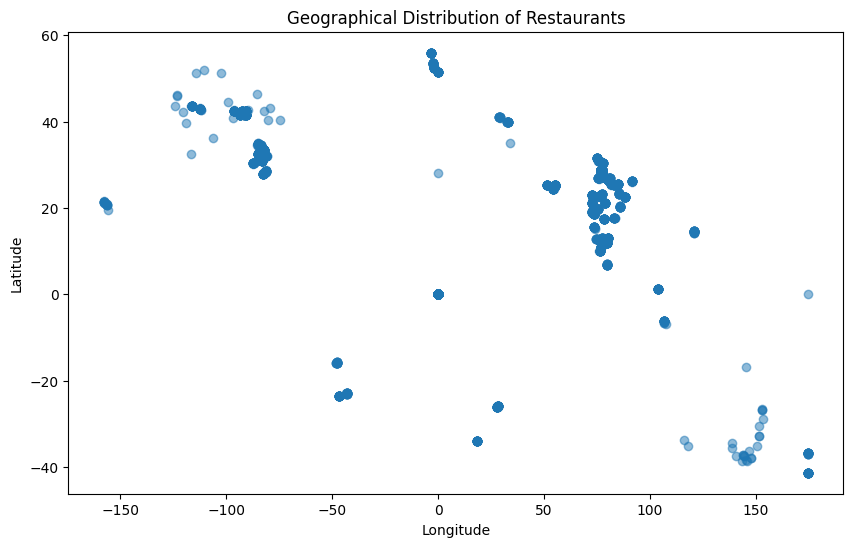

In [13]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['Longitude'],
    df['Latitude'],
    alpha=0.5
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographical Distribution of Restaurants')

plt.show()

In [14]:
df['City'].value_counts().head(10)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Amritsar          21
Bhubaneshwar      21
Guwahati          21
Lucknow           21
Name: count, dtype: int64

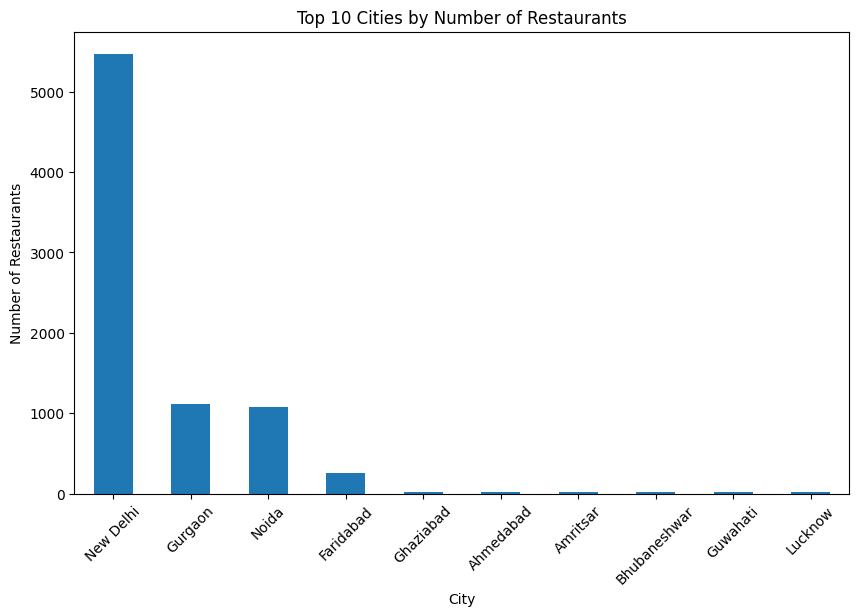

In [15]:
top_cities = df['City'].value_counts().head(10)

top_cities.plot(kind='bar', figsize=(10, 6))

plt.xlabel('City')
plt.ylabel('Number of Restaurants')
plt.title('Top 10 Cities by Number of Restaurants')
plt.xticks(rotation=45)

plt.show()

In [16]:
top_3_city_percentage = (
    df['City'].value_counts().head(3).sum() / len(df)
) * 100

top_3_city_percentage

np.float64(80.31619725683174)

Geographical analysis shows that restaurants are highly concentrated in the Delhi-NCR region. New Delhi has the highest number of restaurants, followed by Gurgaon and Noida. Together, these three cities account for approximately 80.32% of all restaurants in the dataset, indicating a strong geographical clustering in this region.

**Task 4 - Restaurant Chains**

In [17]:
df['Restaurant Name'].value_counts().head(10)

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64

In [18]:
chain_ratings = df.groupby('Restaurant Name')['Aggregate rating'].mean().sort_values(ascending=False)

chain_ratings.head(10)

Restaurant Name
Solita                                      4.9
Spiral - Sofitel Philippine Plaza Manila    4.9
Flat Iron                                   4.9
Sagar Gaire Fast Food                       4.9
Bao                                         4.9
Yellow Dog Eats                             4.9
Gaga Manjero                                4.9
Sushi Masa                                  4.9
Shorts Burger and Shine                     4.9
Sheroes Hangout                             4.9
Name: Aggregate rating, dtype: float64

In [19]:
chain_analysis = df.groupby('Restaurant Name').agg(
    outlet_count=('Restaurant Name', 'count'),
    average_rating=('Aggregate rating', 'mean')
).sort_values('outlet_count', ascending=False)

chain_analysis.head(10)

,outlet_count,average_rating
Restaurant Name,,
Cafe Coffee Day,83,2.419277
Domino's Pizza,79,2.740506
Subway,63,2.907937
Green Chick Chop,51,2.672549
McDonald's,48,3.339583
Keventers,34,2.870588
Pizza Hut,30,3.320000
Giani,29,2.689655
Baskin Robbins,28,1.860714


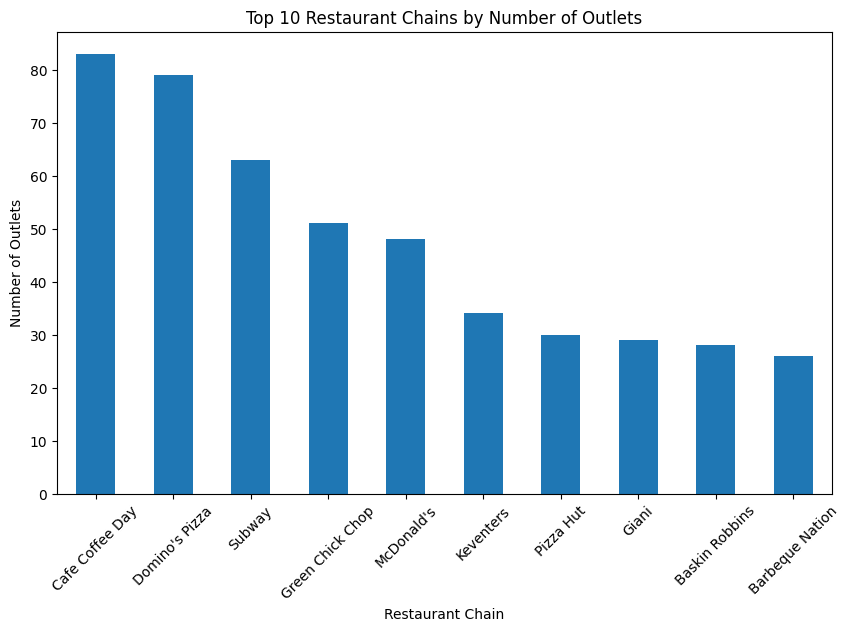

In [20]:
chain_analysis.head(10)['outlet_count'].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.xlabel('Restaurant Chain')
plt.ylabel('Number of Outlets')
plt.title('Top 10 Restaurant Chains by Number of Outlets')
plt.xticks(rotation=45)

plt.show()

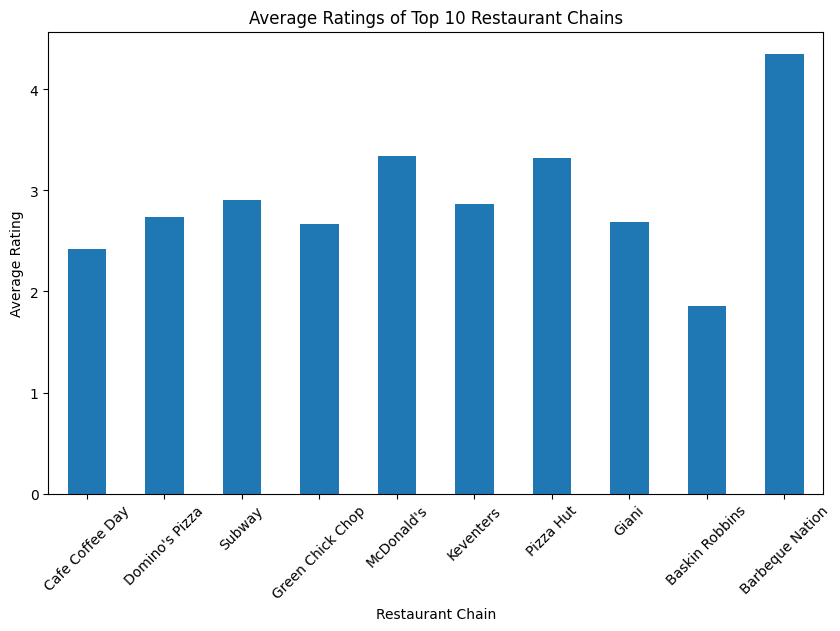

In [21]:
chain_analysis.head(10)['average_rating'].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.xlabel('Restaurant Chain')
plt.ylabel('Average Rating')
plt.title('Average Ratings of Top 10 Restaurant Chains')
plt.xticks(rotation=45)

plt.show()

**The dataset contains several restaurant chains, with Cafe Coffee Day having the highest number of outlets (83), followed by Domino's Pizza (79) and Subway (63). Among the top 10 most widespread chains, Barbeque Nation has the highest average rating of 4.35, while Cafe Coffee Day has an average rating of 2.42. This indicates that restaurant popularity, measured by the number of outlets, does not necessarily correspond to higher customer ratings.**